In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import os


In [14]:
root_folder_path ="/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2"
training_folder_path = root_folder_path+"/train"
testing_folder_path = root_folder_path+"/test"

print("Root Folder Path = ",root_folder_path)
print("Training Folder Path = ",training_folder_path)
print("Testing Folder Path = ",testing_folder_path)



Root Folder Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2
Training Folder Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/train
Testing Folder Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/test


Sample image Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/train/angry/Training_3908.jpg


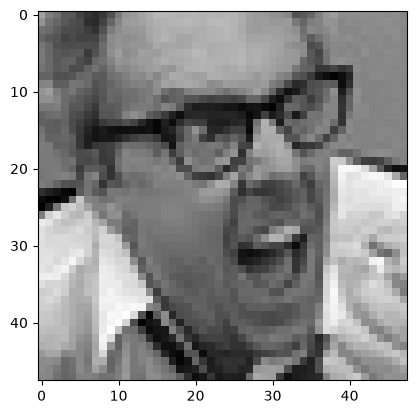

In [15]:
sample_img = training_folder_path+"/angry/Training_3908.jpg"
print("Sample image Path = ",sample_img)
img=image.load_img(sample_img)
plt.imshow(img)

In [16]:
i1 = cv2.imread(sample_img)
i1

array([[[163, 163, 163],
        [128, 128, 128],
        [114, 114, 114],
        ...,
        [139, 139, 139],
        [141, 141, 141],
        [134, 134, 134]],

       [[147, 147, 147],
        [114, 114, 114],
        [102, 102, 102],
        ...,
        [142, 142, 142],
        [138, 138, 138],
        [138, 138, 138]],

       [[112, 112, 112],
        [106, 106, 106],
        [ 92,  92,  92],
        ...,
        [140, 140, 140],
        [141, 141, 141],
        [134, 134, 134]],

       ...,

       [[139, 139, 139],
        [141, 141, 141],
        [136, 136, 136],
        ...,
        [154, 154, 154],
        [171, 171, 171],
        [191, 191, 191]],

       [[140, 140, 140],
        [133, 133, 133],
        [120, 120, 120],
        ...,
        [138, 138, 138],
        [146, 146, 146],
        [158, 158, 158]],

       [[136, 136, 136],
        [134, 134, 134],
        [113, 113, 113],
        ...,
        [146, 146, 146],
        [144, 144, 144],
        [144, 144, 144]]

In [17]:
i1.shape

(48, 48, 3)

In [18]:
train = ImageDataGenerator(rescale = 1/200)
validation = ImageDataGenerator(rescale = 1/200)

# Rescale all images size to a normal 200 X 200 pixel image

# to scale all the images i need to divide by 255
# we need to resize the image using 200 X 200 pixels

In [19]:

# training_folder_path = "/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_Happy_Sad_Project/Training"
# validation_folder_path = "/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_Happy_Sad_Project/Validation" 

print("Training Folder Path = ",training_folder_path)
print("Testing Folder Path = ",testing_folder_path)

train_dataset = train.flow_from_directory(training_folder_path,
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode = 'categorical')

# print("validation_folder_path_happy = ",validation_folder_path)
# validation_dataset = validation.flow_from_directory(validation_folder_path,
#                                           target_size=(200,200),
#                                           batch_size=32,
#                                           class_mode = 'binary')

Training Folder Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/train
Testing Folder Path =  /Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/test
Found 28709 images belonging to 7 classes.


In [20]:
train_dataset.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [21]:
train_dataset.classes

array([0, 0, 0, ..., 6, 6, 6], shape=(28709,), dtype=int32)

In [22]:
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3), activation='relu',
                                                           input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2),

                                    tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
                                    tf.keras.layers.MaxPool2D(2,2),

                                    tf.keras.layers.Flatten(),

                                    tf.keras.layers.Dense(512,activation='relu'),

                                    tf.keras.layers.Dense(7, activation='sigmoid')
                                    ]
                                   )

In [23]:
model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics = ['accuracy'])

In [24]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 147s 163ms/step - accuracy: 0.3617 - loss: 1.7038
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 146s 163ms/step - accuracy: 0.4962 - loss: 1.3181
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 146s 162ms/step - accuracy: 0.6399 - loss: 0.9707
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 146s 163ms/step - accuracy: 0.8264 - loss: 0.4958
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.9553 - loss: 0.1568
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 160ms/step - accuracy: 0.9869 - loss: 0.0630
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 145s 161ms/step - accuracy: 0.9925 - loss: 0.0461
Epoch 8/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 146s 163ms/step - accuracy: 0.9948 - loss: 0.0348
Epoch 9/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 161ms/step - accuracy: 0.9946 - loss: 0.0338
Epoch 10/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 146s 163ms/step - accuracy: 0.9947 - loss: 0.0323
Epoch 11/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 145s 162ms/step - accuracy: 0.9954 - loss: 0.0298
Epoch 12

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    37,749,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,515,856 (288.07 MB)

 Trainable params: 37,757,927 (144.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 37,757,929 (144.04 MB)

In [26]:
# dir_path = "/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_Happy_Sad_Project/Training"
# for i in os.listdir(training_folder_path):
  # print(i)

In [27]:
def get_model_match(match_case):
    match match_case:
        case 0:output = 'angry'
        case 1:output = 'disgust'
        case 2:output = 'fear'
        case 3:output = 'happy'
        case 4:output = 'neutral'
        case 5:output = 'sad'
        case 6:output = 'surprise'
        case _: output = 'Cannot Classify Image'
    return output

File Name =  PrivateTest_1290484.jpg


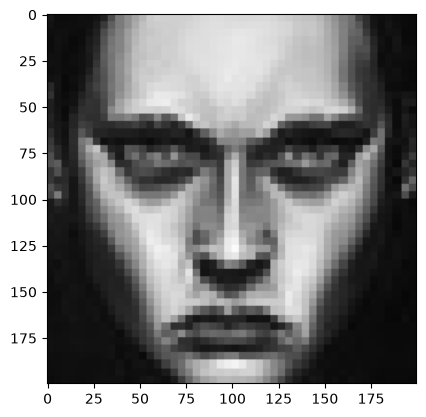

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions =  [[7.5184490e-09 1.4728069e-09 1.1635857e-11 9.3342720e-21 3.1009776e-08
  4.5692071e-04 2.5085993e-13]]
predicted_class_idx =  5
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 5
Predicted Emotion: sad
sad
File Name =  PrivateTest_2918667.jpg


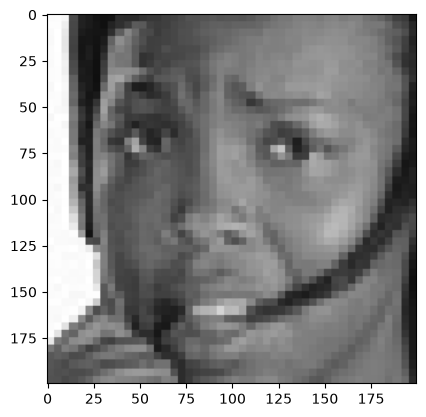

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[4.0620480e-06 3.7766654e-13 3.3920561e-10 1.9959215e-07 7.9415361e-07
  1.6759522e-09 1.3395825e-12]]
predicted_class_idx =  0
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 0
Predicted Emotion: angry
angry
File Name =  PrivateTest_687498.jpg


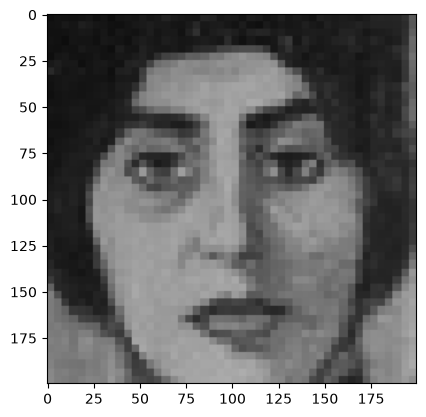

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[2.1686064e-10 2.5336822e-12 5.5881220e-09 1.0743426e-14 4.3286444e-03
  5.0527156e-05 1.9259055e-06]]
predicted_class_idx =  4
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 4
Predicted Emotion: neutral
neutral
File Name =  PrivateTest_3881740.jpg


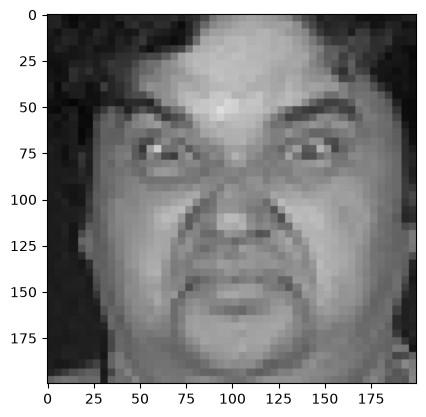

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[2.3458677e-04 3.3496635e-04 4.2978983e-05 7.4406643e-04 9.0631722e-05
  1.0540916e-05 5.7665061e-06]]
predicted_class_idx =  3
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 3
Predicted Emotion: happy
happy
File Name =  PrivateTest_139065.jpg


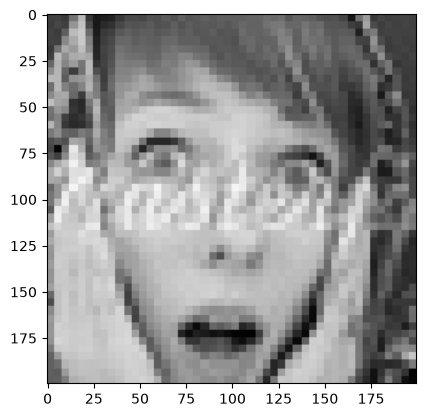

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[6.1883448e-08 4.0217425e-09 1.1493224e-02 9.6941705e-11 2.0821886e-11
  1.2694744e-02 9.2082761e-02]]
predicted_class_idx =  6
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 6
Predicted Emotion: surprise
surprise
File Name =  PrivateTest_807646.jpg


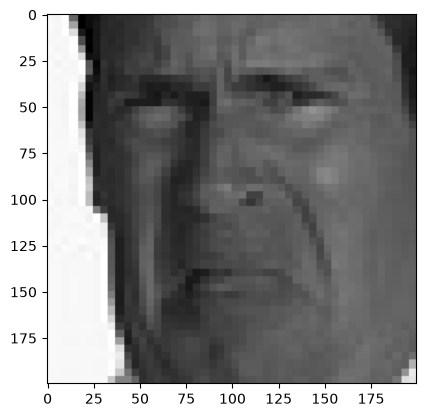

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[5.7400515e-09 5.4916250e-15 1.1887299e-08 1.4662952e-13 5.5478133e-11
  1.8429357e-09 3.2842205e-14]]
predicted_class_idx =  2
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 2
Predicted Emotion: fear
fear
File Name =  PrivateTest_1221822.jpg


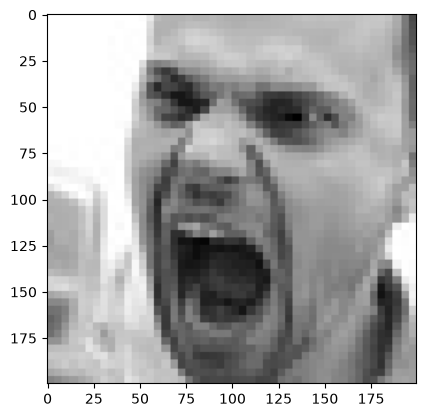

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[1.0622579e-02 3.2065154e-07 4.0572086e-06 1.0587914e-09 4.6568904e-10
  1.6973038e-08 8.9233572e-09]]
predicted_class_idx =  0
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 0
Predicted Emotion: angry
angry
File Name =  PrivateTest_642696.jpg


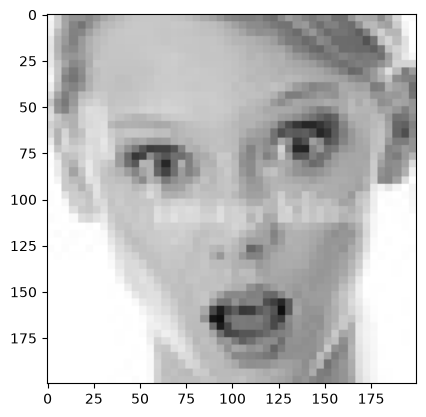

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[1.7404611e-10 5.0745841e-15 7.2165557e-07 3.3047951e-13 1.2167228e-08
  2.9870024e-12 8.3316065e-02]]
predicted_class_idx =  6
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 6
Predicted Emotion: surprise
surprise
File Name =  PrivateTest_687119.jpg


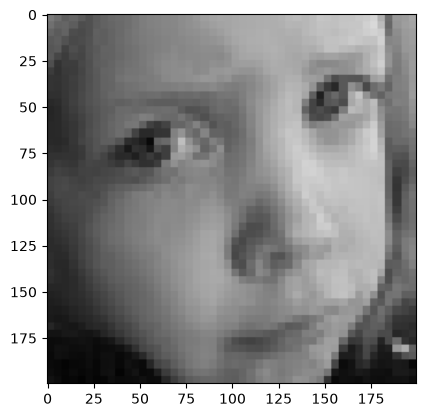

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions =  [[1.1628769e-02 3.7506099e-05 1.5030602e-07 2.4553719e-03 4.1293408e-04
  2.5272419e-04 3.0406382e-09]]
predicted_class_idx =  0
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 0
Predicted Emotion: angry
angry
File Name =  PrivateTest_623230.jpg


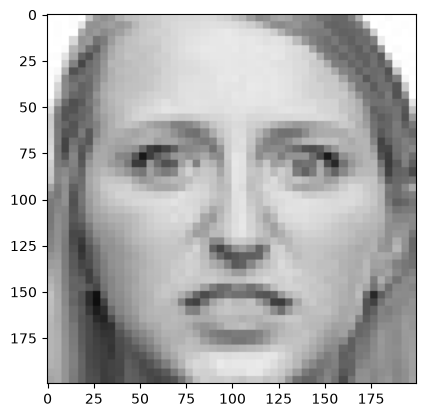

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predictions =  [[7.9521311e-07 3.8791633e-11 1.9443693e-08 5.7454869e-19 2.7318054e-08
  2.6195782e-10 1.5947065e-12]]
predicted_class_idx =  0
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 0
Predicted Emotion: angry
angry
File Name =  PrivateTest_95094.jpg


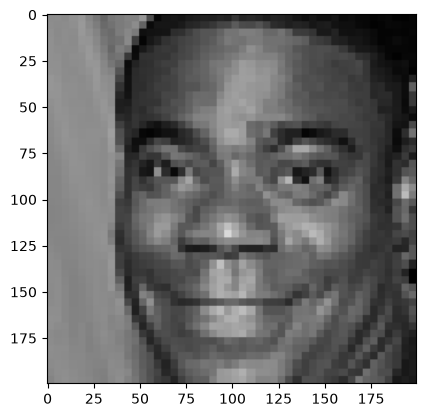

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions =  [[3.1194631e-08 1.1378701e-07 1.2107217e-09 8.3361006e-01 9.4274257e-04
  5.8611033e-07 1.5670295e-06]]
predicted_class_idx =  3
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 3
Predicted Emotion: happy
happy
File Name =  PrivateTest_59059.jpg


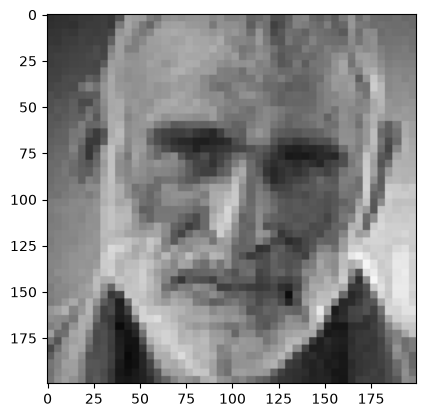

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions =  [[2.0367762e-03 2.0396644e-09 1.2098165e-04 2.6373994e-03 7.5204167e-05
  5.4203643e-04 2.2327426e-06]]
predicted_class_idx =  3
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 3
Predicted Emotion: happy
happy
File Name =  PrivateTest_552501.jpg


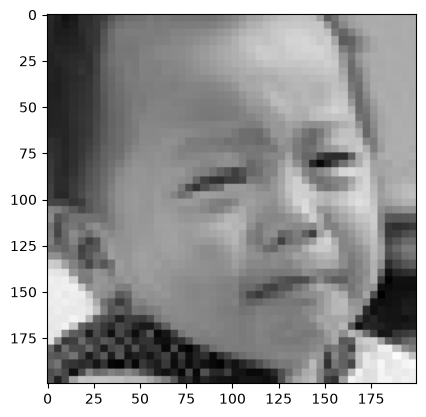

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predictions =  [[1.8885060e-11 1.0824632e-22 9.2686233e-15 1.3588267e-05 8.4534247e-04
  1.4618652e-11 9.9737897e-16]]
predicted_class_idx =  4
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 4
Predicted Emotion: neutral
neutral
File Name =  PrivateTest_218533.jpg


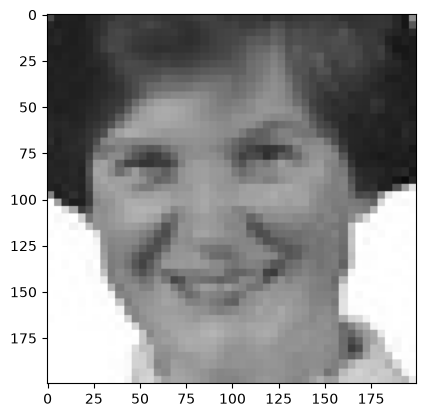

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predictions =  [[7.5688472e-10 1.7109207e-14 3.6052949e-12 9.6826190e-01 3.5002470e-06
  6.3192855e-09 2.0406073e-11]]
predicted_class_idx =  3
class_indices =  {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Predicted Class Index: 3
Predicted Emotion: happy
happy


In [33]:

dir_path = "/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_image_classification_project_2/my_testing_all"
# dir_path ="/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/CNN_Happy_Sad_Project/Testing"
# dir_path = testing_folder_path
for i in os.listdir(dir_path):
  print("File Name = ",i)

  img = image.load_img(dir_path+'//'+i, target_size=(200,200))
  plt.imshow(img)
  plt.show()

  # x = image.img_to_array(img)
  # x = np.expand_dims(x, axis=0)
  # images = np.vstack([x])

  # Load and resize image
  # img = image.load_img('path_to_test_image.jpg', target_size=(200, 200))

  # Convert to array & preprocess
  x = image.img_to_array(img)
  x = x / 255.0  # <-- CRITICAL: Normalize pixel values (0 to 1) like the training data!
  x = np.expand_dims(x, axis=0)
  images = np.vstack([x])

  # val = model.predict(images)
  # print(f"The value = {val}")
  # # print(get_model_match(val))

  # Run prediction
  predictions = model.predict(images)  # Returns array of 7 probabilities, e.g., [[0.01, 0.05, ..., 0.82]]
  print("Predictions = ",predictions)
  # Get the predicted class index
  predicted_class_idx = np.argmax(predictions[0])
  print("predicted_class_idx = ",predicted_class_idx)

  # Get class dictionary from generator: {'angry': 0, 'disgust': 1, ...}
  class_indices = train_dataset.class_indices
  print("class_indices = ",class_indices)
  # Invert it to map index -> class name
  labels_map = {v: k for k, v in class_indices.items()}

  # Final output
  predicted_label = labels_map[predicted_class_idx]
  print(f"Predicted Class Index: {predicted_class_idx}")
  print(f"Predicted Emotion: {predicted_label}")
  print(get_model_match(predicted_class_idx))
  

In [29]:
import gradio as gr
from PIL import Image
import numpy as np

print(gr.__version__)

def predict_mood(image):
    # Resize the image to (200, 200) as expected by the model
    img = image.resize((200, 200))
    # Convert the image to a numpy array
    x = np.array(img)
    # Expand dimensions to create a batch of 1 image
    x = np.expand_dims(x, axis=0)
    # Normalize the image (if the model was trained with normalized inputs)
    # The model was trained with rescale=1/200, so we should apply the same scaling here.
    x = x / 200.0
    # Make prediction
    val = model.predict(x)[0][0]
    # Interpret the prediction
    if val < 0.5:
        return 'Val = ' + str(val) + ' : Happy'
    else:
        return 'Val = ' + str(val) + ' : NOT Happy'

/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/Ann_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6.24.0


In [30]:
iface = gr.Interface(fn = predict_mood,
                     inputs = gr.Image(type= 'pil', label = "Upload an image"),
                     outputs = gr.Text(label= "Predicted Mood"),
                     title = "Mood Classification(Happy/Not Happy)",
                     description="Upload an image to classify if the person is happy or not happy"
                     )
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [31]:
# !nvidia-smi